### 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split

### 2. Load and Explore the Dataset

https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

# Lab Tasks

### Task 1: Basic Discretization

Discretize the 'alcohol' feature into 5 equal-width bins using KBinsDiscretizer. Visualize the original and discretized distributions.

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

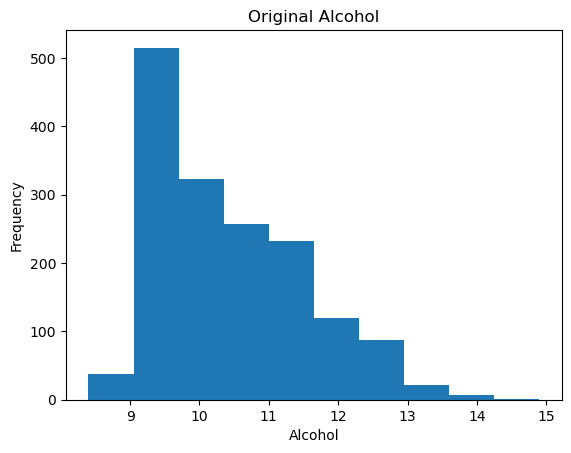

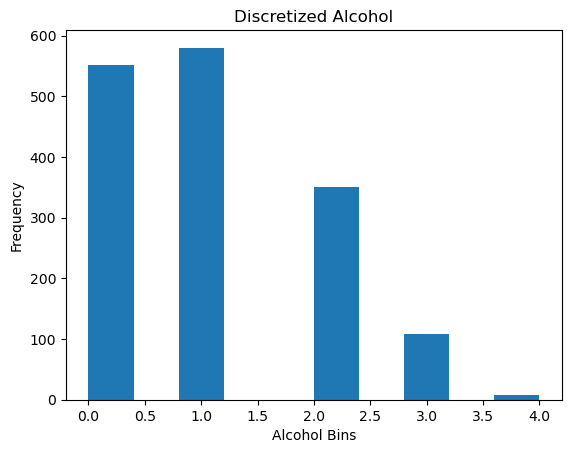

In [27]:
df=pd.read_excel(r'C:\users\waji4\Downloads\winequality-red.xlsx')
alcohol_descretizaed=KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
df['alcohol_descretized']=alcohol_descretizaed.fit_transform(df[['alcohol']])
print(df)
plt.figure()
plt.hist(df['alcohol'])
plt.title("Original Alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.show()
plt.figure()
plt.hist(df['alcohol_descretized'],)
plt.title("Discretized Alcohol")
plt.xlabel("Alcohol Bins")
plt.ylabel("Frequency")
plt.show()

### Task 2: Compare Strategies

Apply KBinsDiscretizer to the 'residual sugar' feature using three different strategies ('uniform', 'quantile') with 4 bins each.

Create histograms to compare the results.

c:\Users\waji4\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


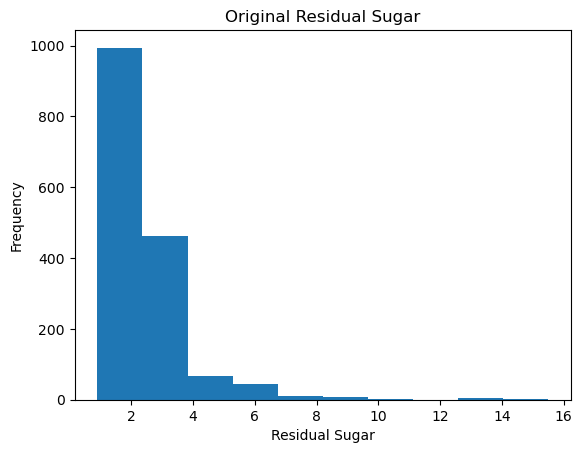

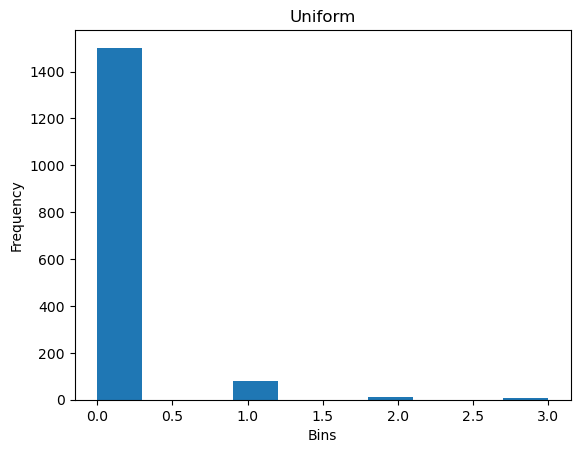

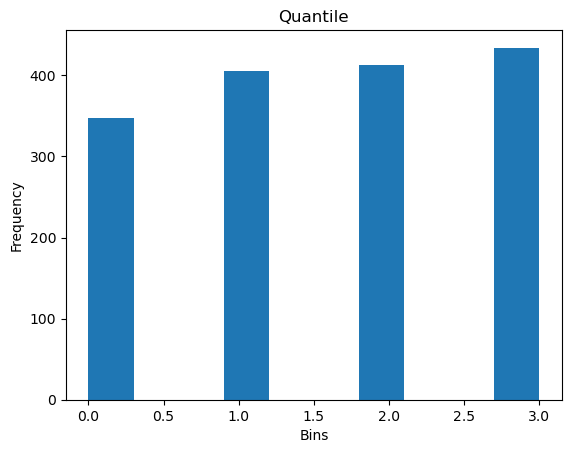

In [31]:
kbin_uniform = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='uniform')
df['sugar_uniform'] = kbin_uniform.fit_transform(df[['residual sugar']])

kbin_quantile = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
df['sugar_quantile'] = kbin_quantile.fit_transform(df[['residual sugar']])

kbin_kmeans = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='kmeans')
df['sugar_kmeans'] = kbin_kmeans.fit_transform(df[['residual sugar']])

plt.figure()
plt.hist(df['residual sugar'])
plt.title("Original Residual Sugar")
plt.xlabel("Residual Sugar")
plt.ylabel("Frequency")

plt.figure()
plt.hist(df['sugar_uniform'])
plt.title("Uniform")
plt.xlabel("Bins")
plt.ylabel("Frequency")

plt.figure()
plt.hist(df['sugar_quantile'])
plt.title("Quantile")
plt.xlabel("Bins")
plt.ylabel("Frequency")

plt.show()

### Task 3: Discretize Multiple Features

Discretize all numerical features (except 'quality') using KBinsDiscretizer with 3 bins and 'quantile' strategy. Create a new DataFrame with the discretized features.

In [35]:
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_features.remove('quality')

kb = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
discretized_array = kb.fit_transform(df[num_features])

df_discretized = pd.DataFrame(discretized_array, columns=num_features)
print(df_discretized)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               1.0               2.0          0.0             0.0        1.0   
1               1.0               2.0          0.0             2.0        2.0   
2               1.0               2.0          0.0             1.0        2.0   
3               2.0               0.0          2.0             0.0        1.0   
4               1.0               2.0          0.0             0.0        1.0   
...             ...               ...          ...             ...        ...   
1594            0.0               2.0          0.0             1.0        2.0   
1595            0.0               1.0          0.0             1.0        0.0   
1596            0.0               1.0          0.0             1.0        1.0   
1597            0.0               2.0          0.0             1.0        1.0   
1598            0.0               0.0          2.0             2.0        0.0   

      free sulfur dioxide  

c:\Users\waji4\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\waji4\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 11 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\waji4\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 12 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\waji4\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width 

### Task 4: Optimal Bin Selection

Experiment with different numbers of bins (3, 5, 7, 10) for the 'fixed acidity' feature and plot

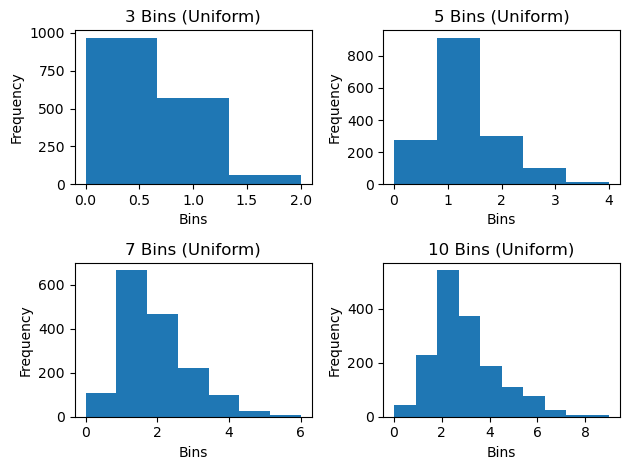

In [38]:
bin_sizes = [3, 5, 7, 10]

plt.figure()

for i, bins in enumerate(bin_sizes, 1):
    kb = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy='uniform')
    df[f'fixed_acidity_binned_{bins}'] = kb.fit_transform(df[['fixed acidity']])
    
    plt.subplot(2, 2, i)
    plt.hist(df[f'fixed_acidity_binned_{bins}'], bins=bins)
    plt.title(f"{bins} Bins (Uniform)")
    plt.xlabel("Bins")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


### Task 5: Custom Binning of Alcohol Content

* The alcohol content in wine typically ranges from about 8% to 15%. Create custom bins for the 'alcohol' feature in the wine dataset as follows:

* Define these custom bins:   bins = [8, 9, 10, 11, 12, 13, 14, 15]

* labels = ['very low', 'low', 'medium-low', 'medium', 'medium-high', 'high', 'very high']

* Create a new column 'alcohol_level' using pd.cut() with these bins and labels

* Create a histogram that shows:

* The original alcohol distribution (use hue='alcohol_level' to color by your bins)

Appropriate title and axis labels

Analyze the relationship between alcohol levels and wine quality by:

* Creating a boxplot of quality scores for each alcohol level

* Calculating the average quality for each alcohol level

In [7]:
import pandas as pd
df = pd.read_csv(r"C:\Users\786\Downloads\archive\winequality-red.csv")
# Define bins and labels
bins = [8, 9, 10, 11, 12, 13, 14, 15]
labels = ['very low', 'low', 'medium-low', 'medium', 'medium-high', 'high', 'very high']

# Create new column
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [14]:
df['alcohol_level'] = pd.cut(df['alcohol'], bins=bins, labels=labels)
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,alcohol_level
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,medium-low
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,medium
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,medium-low
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,medium-low
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6,medium-low


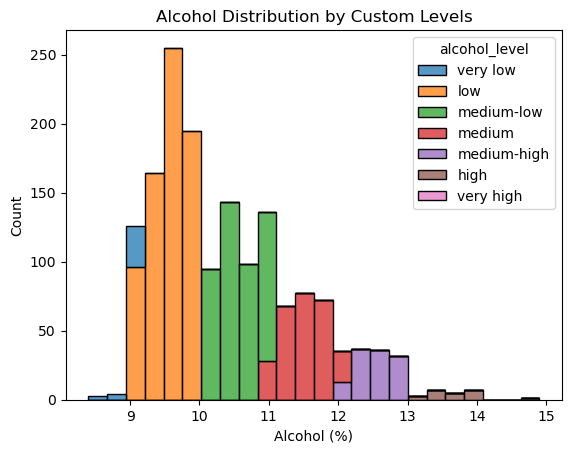

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.histplot(data=df, x='alcohol', hue='alcohol_level', multiple='stack')

'''
multiple = 'stack' -> it will avoid overlapping between the lines and will show the actual count of bars or lines
hue = 'alcohol_level' -> it will represent each category with a different color
'''

plt.title("Alcohol Distribution by Custom Levels")
plt.xlabel("Alcohol (%)")
plt.ylabel("Count")

plt.show()

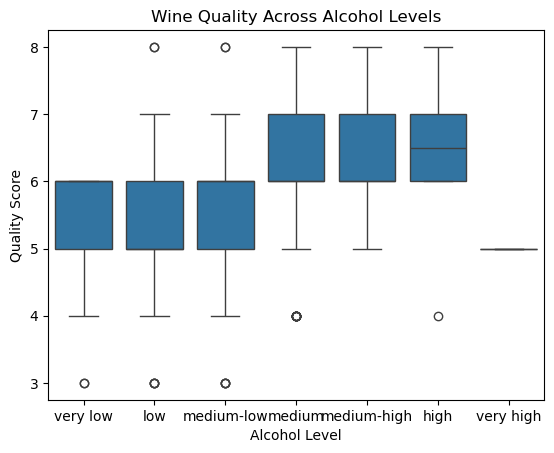

In [11]:
'''Create a new blank plot
Prevents overlapping with previous plots'''
plt.figure()

# Create a boxplot
sns.boxplot(x='alcohol_level', y='quality', data=df)

plt.title("Wine Quality Across Alcohol Levels")
plt.xlabel("Alcohol Level")
plt.ylabel("Quality Score")

plt.show()

In [12]:
avg_quality = df.groupby('alcohol_level')['quality'].mean()
print(avg_quality)

alcohol_level
very low       5.351351
low            5.292958
medium-low     5.691441
medium         6.071161
medium-high    6.423729
high           6.590909
very high      5.000000
Name: quality, dtype: float64


C:\Users\786\AppData\Local\Temp\ipykernel_12224\1846735197.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_quality = df.groupby('alcohol_level')['quality'].mean()
